# MNIST Convolutional Autoencoder

潜在空間の可視化・数字の補間アニメーションを体験する学習プロジェクト。

Using device: mps


/var/folders/5q/knqgd_0156d7tdzxkqq7dgwr0000gn/T/ipykernel_62504/2486385475.py:33: UserWarning: Glyph 12469 (\N{KATAKANA LETTER SA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/5q/knqgd_0156d7tdzxkqq7dgwr0000gn/T/ipykernel_62504/2486385475.py:33: UserWarning: Glyph 12531 (\N{KATAKANA LETTER N}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/5q/knqgd_0156d7tdzxkqq7dgwr0000gn/T/ipykernel_62504/2486385475.py:33: UserWarning: Glyph 12503 (\N{KATAKANA LETTER PU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/5q/knqgd_0156d7tdzxkqq7dgwr0000gn/T/ipykernel_62504/2486385475.py:33: UserWarning: Glyph 12523 (\N{KATAKANA LETTER RU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/5q/knqgd_0156d7tdzxkqq7dgwr0000gn/T/ipykernel_62504/2486385475.py:33: UserWarning: Glyph 30011 (\N{CJK UNIFIED IDEOGRAPH-753B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/5q/knqgd_0156d7tdzxkqq7dgwr0000gn/T/ipyk

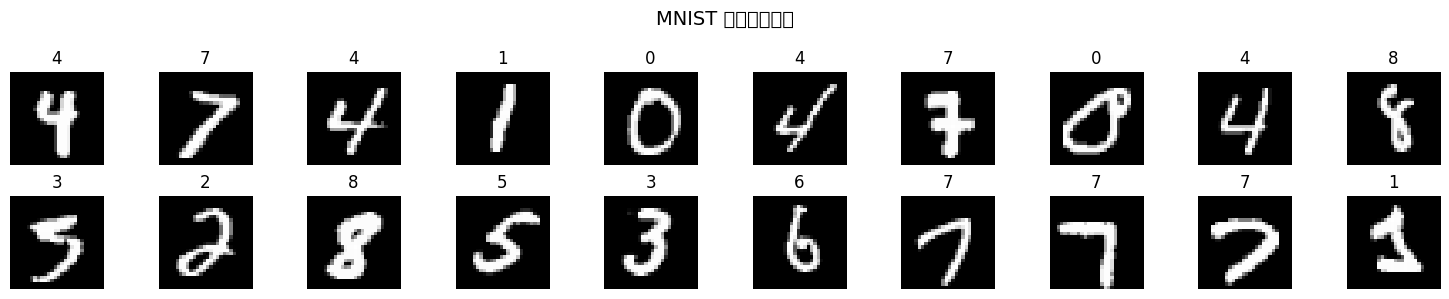

Train: 60000 samples, Test: 10000 samples


In [1]:
# セル1: データ準備
import ssl
ssl._create_default_https_context = ssl._create_unverified_context  # macOS SSL fix

import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

device = torch.device('mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

transform = transforms.Compose([
    transforms.ToTensor(),
])

train_dataset = torchvision.datasets.MNIST(root='./data', train=True,  download=True, transform=transform)
test_dataset  = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=256, shuffle=True,  num_workers=0)
test_loader  = torch.utils.data.DataLoader(test_dataset,  batch_size=256, shuffle=False, num_workers=0)

# サンプル画像を可視化
images, labels = next(iter(train_loader))
fig, axes = plt.subplots(2, 10, figsize=(15, 3))
for i in range(20):
    ax = axes[i // 10, i % 10]
    ax.imshow(images[i].squeeze(), cmap='gray')
    ax.set_title(labels[i].item())
    ax.axis('off')
plt.suptitle('MNIST サンプル画像', fontsize=14)
plt.tight_layout()
plt.show()
print(f'Train: {len(train_dataset)} samples, Test: {len(test_dataset)} samples')

In [16]:
# セル2: モデル定義 (Convolutional Autoencoder, latent_dim=2)
import torch.nn as nn

class Encoder(nn.Module):
    def __init__(self, latent_dim=2):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1),  # 28→14
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1), # 14→7
            nn.ReLU(),
        )
        self.fc = nn.Linear(64 * 7 * 7, latent_dim)

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)


class Decoder(nn.Module):
    def __init__(self, latent_dim=2):
        super().__init__()
        self.fc = nn.Linear(latent_dim, 64 * 7 * 7)
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),  # 7→14
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1,  kernel_size=4, stride=2, padding=1),  # 14→28
            nn.Sigmoid(),
        )

    def forward(self, z):
        x = self.fc(z)
        x = x.view(x.size(0), 64, 7, 7)
        return self.deconv(x)


class Autoencoder(nn.Module):
    def __init__(self, latent_dim=2):
        super().__init__()
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z), z


LATENT_DIM = 8
model = Autoencoder(latent_dim=LATENT_DIM).to(device)
print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f'\nTotal parameters: {total_params:,}')

Autoencoder(
  (encoder): Encoder(
    (conv): Sequential(
      (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (1): ReLU()
      (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (3): ReLU()
    )
    (fc): Linear(in_features=3136, out_features=8, bias=True)
  )
  (decoder): Decoder(
    (fc): Linear(in_features=8, out_features=3136, bias=True)
    (deconv): Sequential(
      (0): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (1): ReLU()
      (2): ConvTranspose2d(32, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (3): Sigmoid()
    )
  )
)

Total parameters: 105,449


Epoch [  1/50]  Loss: 0.021671
Epoch [  5/50]  Loss: 0.018824
Epoch [ 10/50]  Loss: 0.018166
Epoch [ 15/50]  Loss: 0.017840
Epoch [ 20/50]  Loss: 0.017642
Epoch [ 25/50]  Loss: 0.017536
Epoch [ 30/50]  Loss: 0.017455
Epoch [ 35/50]  Loss: 0.017370
Epoch [ 40/50]  Loss: 0.017379
Epoch [ 45/50]  Loss: 0.017200
Epoch [ 50/50]  Loss: 0.017129


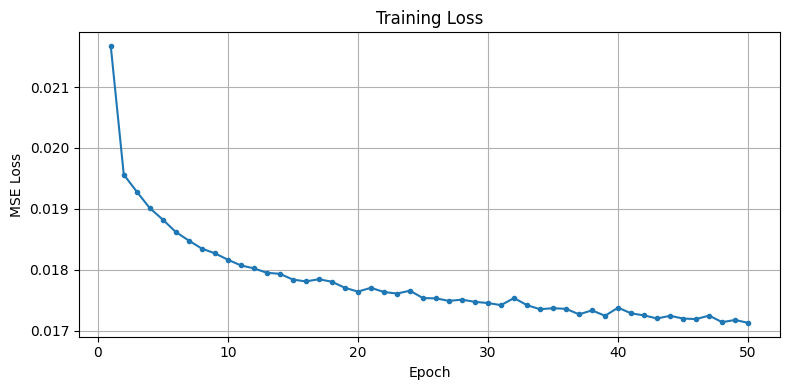

In [18]:
# セル3: 学習ループ
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)
criterion = nn.MSELoss()

EPOCHS = 50
train_losses = []

for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss = 0.0
    for images, _ in train_loader:
        images = images.to(device)
        optimizer.zero_grad()
        recon, _ = model(images)
        loss = criterion(recon, images)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
    epoch_loss = running_loss / len(train_dataset)
    train_losses.append(epoch_loss)
    if epoch % 5 == 0 or epoch == 1:
        print(f'Epoch [{epoch:3d}/{EPOCHS}]  Loss: {epoch_loss:.6f}')

# 損失曲線
plt.figure(figsize=(8, 4))
plt.plot(range(1, EPOCHS + 1), train_losses, marker='o', markersize=3)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training Loss')
plt.grid(True)
plt.tight_layout()
plt.show()

/var/folders/5q/knqgd_0156d7tdzxkqq7dgwr0000gn/T/ipykernel_62504/4277950037.py:21: UserWarning: Glyph 20803 (\N{CJK UNIFIED IDEOGRAPH-5143}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/5q/knqgd_0156d7tdzxkqq7dgwr0000gn/T/ipykernel_62504/4277950037.py:21: UserWarning: Glyph 30011 (\N{CJK UNIFIED IDEOGRAPH-753B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/5q/knqgd_0156d7tdzxkqq7dgwr0000gn/T/ipykernel_62504/4277950037.py:21: UserWarning: Glyph 20687 (\N{CJK UNIFIED IDEOGRAPH-50CF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/5q/knqgd_0156d7tdzxkqq7dgwr0000gn/T/ipykernel_62504/4277950037.py:21: UserWarning: Glyph 20877 (\N{CJK UNIFIED IDEOGRAPH-518D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/5q/knqgd_0156d7tdzxkqq7dgwr0000gn/T/ipykernel_62504/4277950037.py:21: UserWarning: Glyph 27083 (\N{CJK UNIFIED IDEOGRAPH-69CB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/5q/knqg

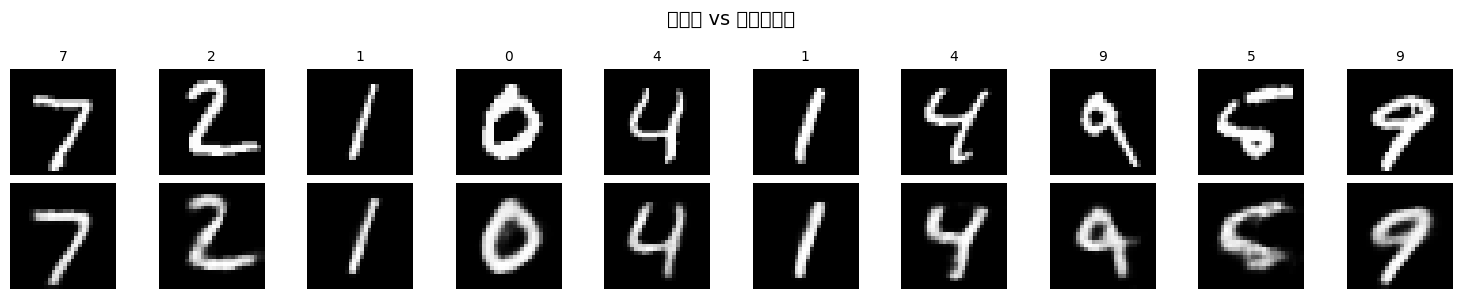

In [19]:
# セル4: 再構成の可視化
model.eval()
test_images, test_labels = next(iter(test_loader))
test_images = test_images.to(device)

with torch.no_grad():
    recon_images, _ = model(test_images)

n = 10
fig, axes = plt.subplots(2, n, figsize=(15, 3))
for i in range(n):
    axes[0, i].imshow(test_images[i].cpu().squeeze(), cmap='gray')
    axes[0, i].set_title(f'{test_labels[i].item()}', fontsize=10)
    axes[0, i].axis('off')
    axes[1, i].imshow(recon_images[i].cpu().squeeze(), cmap='gray')
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('Original', fontsize=11)
axes[1, 0].set_ylabel('Recon', fontsize=11)
plt.suptitle('元画像 vs 再構成画像', fontsize=14)
plt.tight_layout()
plt.show()

/var/folders/5q/knqgd_0156d7tdzxkqq7dgwr0000gn/T/ipykernel_62504/1795398310.py:27: UserWarning: Glyph 28508 (\N{CJK UNIFIED IDEOGRAPH-6F5C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/5q/knqgd_0156d7tdzxkqq7dgwr0000gn/T/ipykernel_62504/1795398310.py:27: UserWarning: Glyph 22312 (\N{CJK UNIFIED IDEOGRAPH-5728}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/5q/knqgd_0156d7tdzxkqq7dgwr0000gn/T/ipykernel_62504/1795398310.py:27: UserWarning: Glyph 31354 (\N{CJK UNIFIED IDEOGRAPH-7A7A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/5q/knqgd_0156d7tdzxkqq7dgwr0000gn/T/ipykernel_62504/1795398310.py:27: UserWarning: Glyph 38291 (\N{CJK UNIFIED IDEOGRAPH-9593}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/5q/knqgd_0156d7tdzxkqq7dgwr0000gn/T/ipykernel_62504/1795398310.py:27: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/5q/knqgd_0156d7

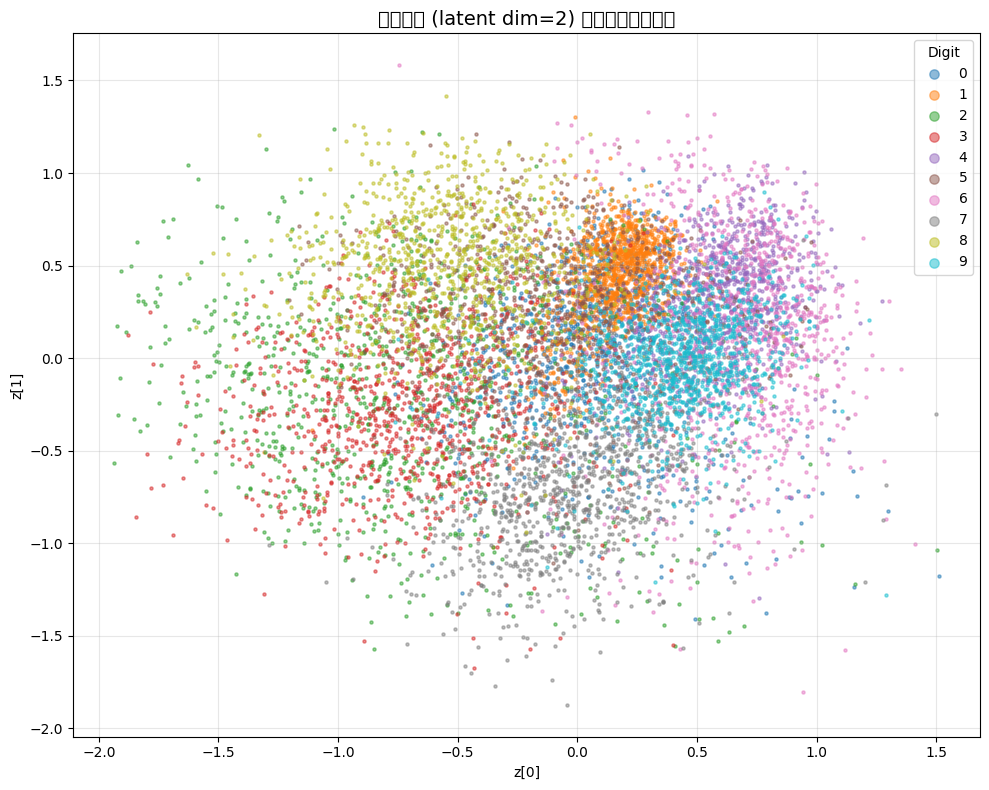

In [20]:
# セル5: 潜在空間の可視化
model.eval()
all_z, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        _, z = model(images)
        all_z.append(z.cpu().numpy())
        all_labels.append(labels.numpy())

all_z      = np.concatenate(all_z,      axis=0)
all_labels = np.concatenate(all_labels, axis=0)

plt.figure(figsize=(10, 8))
cmap = plt.colormaps['tab10'].resampled(10)
for digit in range(10):
    mask = all_labels == digit
    plt.scatter(all_z[mask, 0], all_z[mask, 1],
                color=cmap(digit), label=str(digit),
                alpha=0.5, s=5)
plt.legend(title='Digit', markerscale=3, loc='best')
plt.title('潜在空間 (latent dim=2) のクラスタリング', fontsize=14)
plt.xlabel('z[0]')
plt.ylabel('z[1]')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [22]:
# セル6: 数字の補間アニメーション
from matplotlib import animation
from IPython.display import HTML

def get_sample_z(digit, n=10):
    """指定した数字の潜在ベクトルをn個取得して平均を返す"""
    model.eval()
    collected = []
    with torch.no_grad():
        for images, labels in test_loader:
            mask = labels == digit
            if mask.sum() == 0:
                continue
            imgs = images[mask].to(device)
            _, z = model(imgs)
            collected.append(z.cpu())
            if sum(x.size(0) for x in collected) >= n:
                break
    z_all = torch.cat(collected, dim=0)[:n]
    return z_all.mean(dim=0)

DIGIT_A, DIGIT_B = 0, 1   # ← ここを変えると別の補間になる
STEPS = 30

z_a = get_sample_z(DIGIT_A)
z_b = get_sample_z(DIGIT_B)

# 線形補間
alphas = torch.linspace(0, 1, STEPS)
interp_z = torch.stack([((1 - a) * z_a + a * z_b) for a in alphas]).to(device)

with torch.no_grad():
    interp_imgs = model.decoder(interp_z).cpu().squeeze(1).numpy()

fig, ax = plt.subplots(figsize=(3, 3))
ax.axis('off')
im = ax.imshow(interp_imgs[0], cmap='gray', vmin=0, vmax=1)
title = ax.set_title(f'{DIGIT_A} → {DIGIT_B}  (0/{STEPS-1})', fontsize=12)

def update(frame):
    im.set_data(interp_imgs[frame])
    title.set_text(f'{DIGIT_A} → {DIGIT_B}  ({frame}/{STEPS-1})')
    return [im, title]

anim = animation.FuncAnimation(fig, update, frames=STEPS, interval=80, blit=True)
plt.close()
HTML(anim.to_jshtml())

DN Epoch [  1/20]  Loss: 0.070550
DN Epoch [  5/20]  Loss: 0.049576
DN Epoch [ 10/20]  Loss: 0.047531
DN Epoch [ 15/20]  Loss: 0.046469
DN Epoch [ 20/20]  Loss: 0.045765


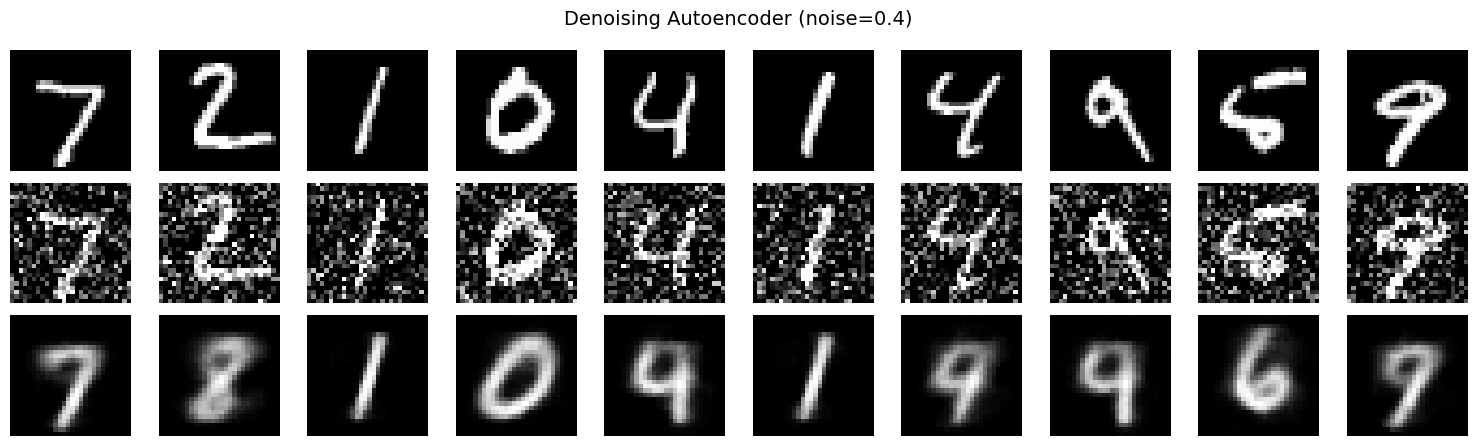

In [15]:
# セル7 (オプション): Denoising Autoencoder
# 同じモデルアーキテクチャ、ノイズ付き入力→クリーン出力を学習

NOISE_FACTOR = 0.4
DENOISE_EPOCHS = 20

denoising_model = Autoencoder(latent_dim=LATENT_DIM).to(device)
dn_optimizer = torch.optim.Adam(denoising_model.parameters(), lr=1e-3)

dn_losses = []
for epoch in range(1, DENOISE_EPOCHS + 1):
    denoising_model.train()
    running_loss = 0.0
    for images, _ in train_loader:
        images = images.to(device)
        noisy = images + NOISE_FACTOR * torch.randn_like(images)
        noisy = noisy.clamp(0, 1)
        dn_optimizer.zero_grad()
        recon, _ = denoising_model(noisy)
        loss = criterion(recon, images)   # ターゲットはクリーン画像
        loss.backward()
        dn_optimizer.step()
        running_loss += loss.item() * images.size(0)
    epoch_loss = running_loss / len(train_dataset)
    dn_losses.append(epoch_loss)
    if epoch % 5 == 0 or epoch == 1:
        print(f'DN Epoch [{epoch:3d}/{DENOISE_EPOCHS}]  Loss: {epoch_loss:.6f}')

# Denoising 結果の可視化
denoising_model.eval()
test_imgs, _ = next(iter(test_loader))
test_imgs = test_imgs.to(device)
noisy_imgs = (test_imgs + NOISE_FACTOR * torch.randn_like(test_imgs)).clamp(0, 1)

with torch.no_grad():
    clean_recon, _ = denoising_model(noisy_imgs)

n = 10
fig, axes = plt.subplots(3, n, figsize=(15, 4.5))
row_labels = ['Original', 'Noisy', 'Denoised']
imgs_list = [test_imgs, noisy_imgs, clean_recon]
for row, (row_imgs, row_label) in enumerate(zip(imgs_list, row_labels)):
    for col in range(n):
        axes[row, col].imshow(row_imgs[col].cpu().squeeze(), cmap='gray')
        axes[row, col].axis('off')
    axes[row, 0].set_ylabel(row_label, fontsize=11)
plt.suptitle(f'Denoising Autoencoder (noise={NOISE_FACTOR})', fontsize=14)
plt.tight_layout()
plt.show()